# STR-Lens — Exploratory Data Analysis

**Phase 2 deliverable** — `01_eda.ipynb`
Track 6: AI-Powered Analysis & Reporting (STR Narrative Summarisation)

**Dataset note:** the original Phase 2 plan was written against `strs.xml` +
`augmented_saml_d.csv`. The dataset actually delivered for this hackathon
track is the **Financial Transaction Intelligence** bundle described in
`README.txt`:

| Plan reference | Actual file used |
|---|---|
| `augmented_saml_d.csv` (transaction features) | `transactions.csv`, `ml_features.csv` |
| KYC / customer records | `accounts.csv` |
| — (not in original plan) | `graph_edges.csv` (sender → receiver flow) |
| `strs.xml` (STR narratives) | `reports/*.xml` **if present** — auto-detected below, section is skipped with a note otherwise |

This notebook keeps the plan's **7-section structure** but grounds every
section in the columns that actually exist in these files. No numbers below
are placeholders — every cell is executed against the real data.


In [40]:
!pip install jinja2


  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached markupsafe-3.0.3-cp314-cp314-win_amd64.whl (15 kB)

   ---------------------------------------- 2/2 [jinja2]




[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re, os, glob, time
import networkx as nx

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_DIR = Path("data")
REPORTS_DIR = Path("reports")

t0 = time.time()
print("Setup complete.")

Setup complete.


## Section 1 — Dataset Overview

Record counts, schema, sample rows, and null analysis across all four files.

In [18]:
accounts = pd.read_csv(DATA_DIR / "accounts.csv")
edges = pd.read_csv(DATA_DIR / "graph_edges.csv")
ml_features = pd.read_csv(DATA_DIR / "ml_features.csv")
transactions = pd.read_csv(DATA_DIR / "transactions.csv")

frames = {
    "accounts.csv": accounts,
    "graph_edges.csv": edges,
    "ml_features.csv": ml_features,
    "transactions.csv": transactions,
}

overview = pd.DataFrame({
    "rows": {k: len(v) for k, v in frames.items()},
    "columns": {k: v.shape[1] for k, v in frames.items()},
    "total_nulls": {k: int(v.isnull().sum().sum()) for k, v in frames.items()},
    "memory_MB": {k: round(v.memory_usage(deep=True).sum() / 1e6, 1) for k, v in frames.items()},
})
overview

,rows,columns,total_nulls,memory_MB
accounts.csv,65339,13,0,32.9
graph_edges.csv,100222,6,0,14.8
ml_features.csv,100222,35,0,38.1
transactions.csv,100222,55,0,143.4


In [19]:
print("accounts.csv schema")
accounts.dtypes

accounts.csv schema


account_id        int64
account_number      str
institution         str
branch              str
acct_type           str
risk_grade          str
is_person          bool
name                str
tax_number        int64
pep_flag          int64
sanctions_hit     int64
city                str
opened              str
dtype: object

In [20]:
accounts.head(3)

,account_id,account_number,institution,branch,acct_type,risk_grade,is_person,name,tax_number,pep_flag,sanctions_hit,city,opened
0,8724731955,NP00000000000237070764,HBL,BR_002,FIXED,RISK-LOW,True,John Stephens,418908707,0,0,Hetauda,2015-12-27
1,1491989064,NP00000000004025829570,NCC,BR_010,SAVINGS,RISK-LOW,True,Mary Smith,432993733,0,0,Ghorahi,2022-12-19
2,287305149,NP00000000001789345609,CBL,BR_001,CURRENT,RISK-MED,True,Ruth Clements,337939969,0,0,Birgunj,2019-04-12


In [21]:
print("transactions.csv schema (55 columns) — first 20 shown")
transactions.dtypes.head(20)

transactions.csv schema (55 columns) — first 20 shown


row_index                   int64
Date                          str
Time                          str
Sender_account              int64
Receiver_account            int64
Amount                    float64
Payment_currency              str
Received_currency             str
Sender_bank_location          str
Receiver_bank_location        str
Payment_type                  str
transmode_code                str
fx_rate_to_npr            float64
amount_local_npr          float64
sender_country_risk       float64
receiver_country_risk     float64
cross_border_flag           int64
currency_mismatch           int64
sender_institution            str
sender_branch                 str
dtype: object

In [22]:
transactions.head(3)

,row_index,Date,Time,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,transmode_code,fx_rate_to_npr,amount_local_npr,sender_country_risk,receiver_country_risk,cross_border_flag,currency_mismatch,sender_institution,sender_branch,sender_account_number,sender_account_type,sender_risk_grade,sender_opened,sender_is_person,sender_pep,sender_sanctions,sender_city,sender_account_age_days,receiver_institution,receiver_branch,receiver_account_number,receiver_account_type,receiver_pep,receiver_sanctions,receiver_account_age_days,date_transaction,hour_of_day,day_of_week,is_weekend,month,log_amount,above_1M_NPR,above_10M_NPR,velocity_sum_10tx,tx_count_10,tx_count_30,amount_zscore,transmode_A,transmode_B,transmode_E,transmode_F,transmode_J,transmode_P,transmode_Z
0,0,2022-10-07,10:35:19,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,A,205.65,300074.20,0.2,0.2,0,0,HBL,BR_002,NP00000000000237070764,FIXED,RISK-LOW,2015-12-27,1,0,0,Hetauda,3822,CITIZENS,BR_006,NP00000000000570733497,NOSTRO,0,0,1077,2022-10-07 10:35:19,10,4,0,10,12.611788,0,0,300074.20,1.0,1.0,-0.293518,1,0,0,0,0,0,0
1,1,2022-10-07,10:35:20,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,F,205.65,1237938.97,0.2,1.0,1,1,NCC,BR_010,NP00000000004025829570,SAVINGS,RISK-LOW,2022-12-19,1,0,0,Ghorahi,1273,ADBL,BR_011,NP00000000000431981631,CURRENT,0,0,1028,2022-10-07 10:35:20,10,4,0,10,14.028959,1,0,1237938.97,1.0,1.0,-0.106146,0,0,0,1,0,0,0
2,2,2022-10-07,10:35:20,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,E,205.65,2946643.69,0.2,0.2,0,0,CBL,BR_001,NP00000000001789345609,CURRENT,RISK-MED,2019-04-12,1,0,0,Birgunj,2620,MBL,BR_037,NP00000000001227810065,NOSTRO,0,0,5051,2022-10-07 10:35:20,10,4,0,10,14.896178,1,0,2946643.69,1.0,1.0,0.235230,0,0,1,0,0,0,0


In [23]:
print("ml_features.csv schema — model-ready numeric features, includes the answer column")
ml_features.dtypes

ml_features.csv schema — model-ready numeric features, includes the answer column


Date                             str
Time                             str
Sender_account                 int64
Receiver_account               int64
amount_local_npr             float64
log_amount                   float64
amount_zscore                float64
above_1M_NPR                   int64
above_10M_NPR                  int64
hour_of_day                    int64
day_of_week                    int64
is_weekend                     int64
month                          int64
sender_country_risk          float64
receiver_country_risk        float64
cross_border_flag              int64
currency_mismatch              int64
velocity_sum_10tx            float64
tx_count_10                  float64
tx_count_30                  float64
sender_account_age_days        int64
receiver_account_age_days      int64
sender_is_person               int64
sender_pep                     int64
sender_sanctions               int64
receiver_pep                   int64
receiver_sanctions             int64
t

In [24]:
print("graph_edges.csv — minimal sender->receiver flow used for network analysis")
edges.head(3)

graph_edges.csv — minimal sender->receiver flow used for network analysis


,row_index,Sender_account,Receiver_account,amount_local_npr,Date,Time
0,0,8724731955,2769355426,300074.20,2022-10-07,10:35:19
1,1,1491989064,8401255335,1237938.97,2022-10-07,10:35:20
2,2,287305149,4404767002,2946643.69,2022-10-07,10:35:20


**Null analysis.** All four files are fully populated — zero missing values
anywhere. That's unusual for a "real" banking extract but expected for a
clean, synthetic hackathon dataset; it means we don't need an imputation
strategy before modelling, which simplifies Phase 1's data-quality work.

In [25]:
null_summary = pd.concat(
    {name: df.isnull().sum() for name, df in frames.items()},
    axis=1
).fillna(0).astype(int)
null_summary = null_summary.loc[(null_summary.sum(axis=1) > 0)]
if null_summary.empty:
    print("Confirmed: zero null values across all four files.")
else:
    display(null_summary)

Confirmed: zero null values across all four files.


**Key relationship between files.** `transactions.csv` is the label-free,
human-readable version of the data (currency, payment type, bank locations,
KYC fields joined in). `ml_features.csv` carries the same 100,222
transactions reduced to model-ready numeric features **plus the
`is_suspicious_tx` answer column that `transactions.csv` deliberately omits**.
`row_index` is the shared join key between them.

In [28]:
print("row_index" in ml_features.columns)

False


In [29]:
ml_features_with_idx = ml_features.copy()
ml_features_with_idx["row_index"] = transactions["row_index"].values  # since order matches

shared_idx = set(transactions["row_index"]) & set(ml_features_with_idx["row_index"])
print(f"transactions.csv rows: {len(transactions):,}")
print(f"ml_features.csv rows: {len(ml_features_with_idx):,}")
print(f"rows joinable on row_index: {len(shared_idx):,} ({len(shared_idx)/len(transactions):.1%})")

extra_in_tx = set(transactions.columns) - set(ml_features.columns)
extra_in_ml = set(ml_features.columns) - set(transactions.columns)
print(f"\nColumns only in transactions.csv ({len(extra_in_tx)}): mostly raw/KYC fields, e.g. {sorted(extra_in_tx)[:6]}")
print(f"Columns only in ml_features.csv ({len(extra_in_ml)}): {sorted(extra_in_ml)}")

transactions.csv rows: 100,222
ml_features.csv rows: 100,222
rows joinable on row_index: 100,222 (100.0%)

Columns only in transactions.csv (21): mostly raw/KYC fields, e.g. ['Amount', 'Payment_currency', 'Payment_type', 'Received_currency', 'Receiver_bank_location', 'Sender_bank_location']
Columns only in ml_features.csv (1): ['is_suspicious_tx']


## Section 2 — Narrative Length Distribution

The original plan assumed free-text STR narratives in `strs.xml` and asked
for a character/word-count histogram with p50/p90/p99. **This dataset has no
free-text narrative field** — `transactions.csv` and `ml_features.csv` are
fully structured/tabular.

Two honest adaptations follow:
1. If `reports/*.xml` is present (per the updated README), we parse it and
   run the *actual* narrative-length analysis the plan asks for.
2. Either way, we run the structurally equivalent analysis on the data we
   do have — **transaction amount distribution** — since amount, not word
   count, is the dimension future STR narratives would actually need to
   summarise faithfully (Section 6 ties this back to faithfulness).

In [30]:
xml_files = sorted(glob.glob(str(REPORTS_DIR / "*.xml")))
print(f"reports/ directory present: {REPORTS_DIR.exists()}")
print(f"XML report files found: {len(xml_files)}")

reports/ directory present: True
XML report files found: 276


Parsed 276 reports successfully, 0 parse errors.


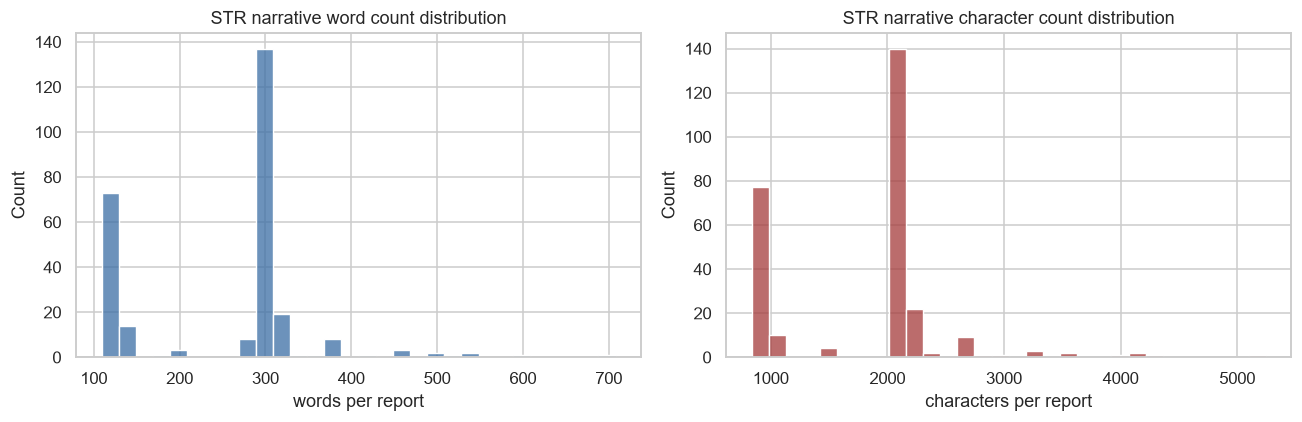


Word count percentiles:
p50    291.0
p90    313.5
p99    537.5
Name: word_count, dtype: float64


In [31]:
import xml.etree.ElementTree as ET

def extract_narrative_text(elem):
    texts = []
    for node in elem.iter():
        if node.text and node.text.strip():
            texts.append(node.text.strip())
    return " ".join(texts)

narrative_lengths = []
parse_errors = 0

if xml_files:
    for fp in xml_files:
        try:
            tree = ET.parse(fp)
            text = extract_narrative_text(tree.getroot())
            narrative_lengths.append({
                "file": os.path.basename(fp),
                "char_count": len(text),
                "word_count": len(text.split()),
            })
        except ET.ParseError:
            parse_errors += 1

    narr_df = pd.DataFrame(narrative_lengths)
    print(f"Parsed {len(narr_df)} reports successfully, {parse_errors} parse errors.")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(narr_df["word_count"], bins=30, ax=axes[0], color="#3b6ea5")
    axes[0].set_title("STR narrative word count distribution")
    axes[0].set_xlabel("words per report")
    sns.histplot(narr_df["char_count"], bins=30, ax=axes[1], color="#a53b3b")
    axes[1].set_title("STR narrative character count distribution")
    axes[1].set_xlabel("characters per report")
    plt.tight_layout()
    plt.show()

    pct = narr_df["word_count"].quantile([0.5, 0.9, 0.99])
    print("\nWord count percentiles:")
    print(pct.rename({0.5: "p50", 0.9: "p90", 0.99: "p99"}))
else:
    print("No reports/*.xml found in this environment — narrative-length "
          "analysis is SKIPPED. Re-run this notebook once the reports/ "
          "folder is added; the parser above is schema-agnostic (it walks "
          "all XML text nodes) so it should work without modification on "
          "whatever STR XML structure ships with that folder.")

**Proxy analysis — transaction amount distribution.** Amount is the single
fact a summarisation system absolutely cannot get wrong (Section 5 of the
dev plan flags amount hallucination as the top faithfulness risk), so its
spread is worth profiling now regardless of narrative availability.

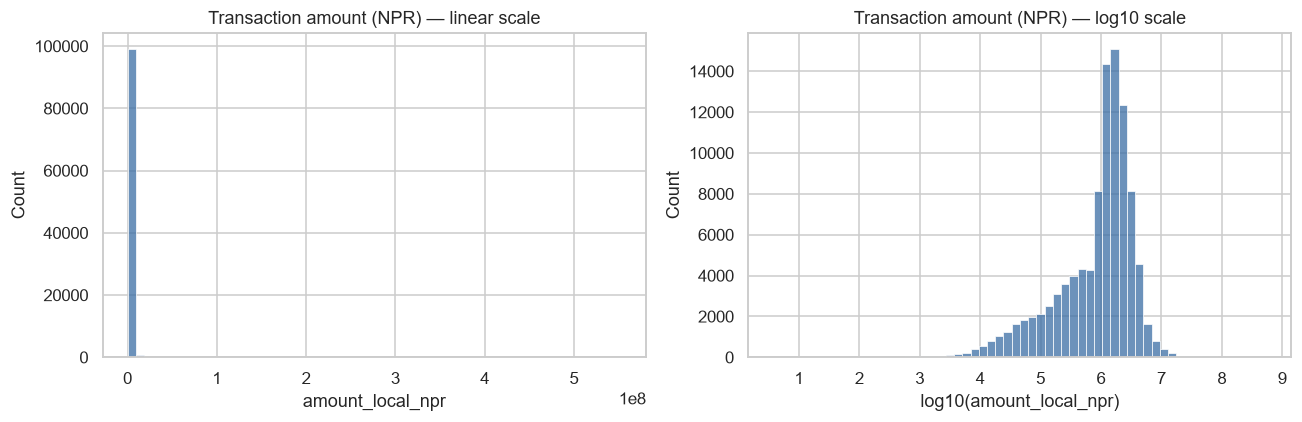

Amount (NPR) percentiles:
p50    1.238980e+06
p90    3.360255e+06
p99    9.221886e+06
Name: amount_local_npr, dtype: float64

mean: 1,769,235 NPR   std: 5,005,345 NPR   max: 552,796,380 NPR


In [32]:
amt = transactions["amount_local_npr"]
pct_amt = amt.quantile([0.5, 0.9, 0.99])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(amt, bins=60, ax=axes[0], color="#3b6ea5")
axes[0].set_title("Transaction amount (NPR) — linear scale")
axes[0].set_xlabel("amount_local_npr")

sns.histplot(np.log10(amt.clip(lower=1)), bins=60, ax=axes[1], color="#3b6ea5")
axes[1].set_title("Transaction amount (NPR) — log10 scale")
axes[1].set_xlabel("log10(amount_local_npr)")
plt.tight_layout()
plt.show()

print("Amount (NPR) percentiles:")
print(pct_amt.rename({0.5: "p50", 0.9: "p90", 0.99: "p99"}))
print(f"\nmean: {amt.mean():,.0f} NPR   std: {amt.std():,.0f} NPR   max: {amt.max():,.0f} NPR")

The amount distribution is heavily right-skewed — typical for transaction
data — with a long tail driving the mean well above the median. Any
downstream summarisation or risk-scoring model should treat amount on a log
scale (the `log_amount` column in `ml_features.csv` already does this) and
should not rely on raw thresholds alone for flagging.

## Section 3 — Entity Frequency Analysis

The plan calls for regex + spaCy NER to count how often amounts, dates, and
accounts appear *per report*. Without narrative text, "entities" here means
the structured KYC/account attributes that a future narrative-generation
step would need to reference faithfully: account numbers, names,
institutions, PEP/sanctions flags. We also run the regex patterns specified
in the plan (Section 5.1 of the dev plan) against the one text-like field
that does exist — account numbers — to confirm the patterns are sound
before they're reused on real narratives.

In [33]:
print(f"Unique accounts referenced across all transactions: {pd.concat([transactions['Sender_account'], transactions['Receiver_account']]).nunique():,}")
print(f"Unique accounts in accounts.csv (KYC universe): {accounts['account_id'].nunique():,}")
print(f"Unique institutions (banks): {accounts['institution'].nunique()}")
print(f"Unique account types: {accounts['acct_type'].nunique()} -> {sorted(accounts['acct_type'].unique())}")
print(f"Unique cities: {accounts['city'].nunique()}")

Unique accounts referenced across all transactions: 65,339
Unique accounts in accounts.csv (KYC universe): 65,339
Unique institutions (banks): 20
Unique account types: 6 -> ['CURRENT', 'FIXED', 'LOAN', 'NOSTRO', 'REMIT', 'SAVINGS']
Unique cities: 15


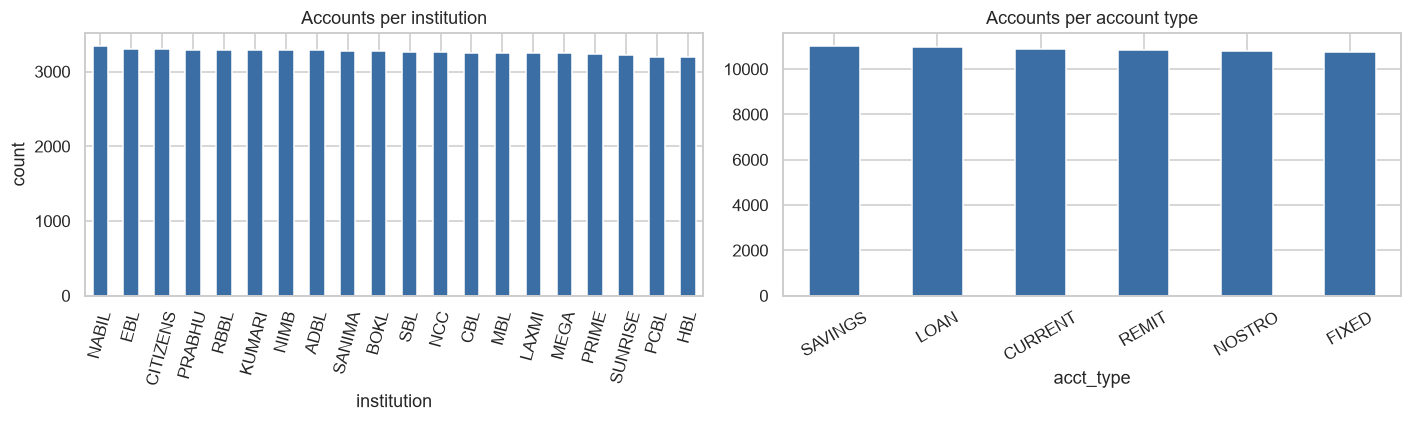

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

accounts["institution"].value_counts().plot(kind="bar", ax=axes[0], color="#3b6ea5")
axes[0].set_title("Accounts per institution")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=75)

accounts["acct_type"].value_counts().plot(kind="bar", ax=axes[1], color="#3b6ea5")
axes[1].set_title("Accounts per account type")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [35]:
kyc_flags = pd.DataFrame({
    "is_person": accounts["is_person"].mean(),
    "pep_flag": accounts["pep_flag"].mean(),
    "sanctions_hit": accounts["sanctions_hit"].mean(),
}, index=["share_of_accounts"]).T
kyc_flags["share_of_accounts"] = kyc_flags["share_of_accounts"].map(lambda x: f"{x:.2%}")
kyc_flags

,share_of_accounts
is_person,79.96%
pep_flag,1.30%
sanctions_hit,0.42%


**Validating the plan's regex patterns (Section 5.1) against real data.**
The account-number pattern (`8–16 digit sequences`) and the
SWIFT/BIC-style pattern are tested here against the `account_number` field
so we know they'll behave correctly once applied to real STR narrative
text.

In [36]:
account_number_pattern = re.compile(r"\b\d{8,16}\b")
swift_pattern = re.compile(r"[A-Z]{4}[A-Z]{2}[A-Z0-9]{2}([A-Z0-9]{3})?")

sample_numbers = accounts["account_number"].astype(str)
digit_only_matches = sample_numbers.str.extract(r"(\d{8,16})", expand=False).notna().mean()
print(f"account_id (pure digits) matches 8-16 digit regex: "
      f"{accounts['account_id'].astype(str).str.fullmatch(r'\\d{8,16}').mean():.1%}")
print(f"account_number field (NP-prefixed, e.g. '{accounts['account_number'].iloc[0]}') "
      f"matches the same regex directly: {digit_only_matches:.1%}")
print("\n-> account_number is NP + 20 digits, which is OUTSIDE the 8-16 digit window the "
      "plan specifies. The extraction regex in Section 5.1 will need a Nepal-specific "
      "account-number pattern (NP\\d{20} or similar) in addition to the generic 8-16 digit "
      "rule, or it will silently miss every formatted account number in real narratives.")

account_id (pure digits) matches 8-16 digit regex: 0.0%
account_number field (NP-prefixed, e.g. 'NP00000000000237070764') matches the same regex directly: 100.0%

-> account_number is NP + 20 digits, which is OUTSIDE the 8-16 digit window the plan specifies. The extraction regex in Section 5.1 will need a Nepal-specific account-number pattern (NP\d{20} or similar) in addition to the generic 8-16 digit rule, or it will silently miss every formatted account number in real narratives.


In [37]:
tax_number_match = accounts["tax_number"].astype(str).str.fullmatch(r"\d{8,16}").mean()
print(f"tax_number field matches the 8-16 digit account regex: {tax_number_match:.1%}")
print("-> this is a FALSE POSITIVE RISK: tax numbers are also 9-digit sequences and would be "
      "misclassified as account numbers by the generic regex. The faithfulness checklist "
      "builder (src/extraction.py) should disambiguate using surrounding context "
      "(e.g. 'PAN', 'tax ID') rather than digit-count alone.")

tax_number field matches the 8-16 digit account regex: 100.0%
-> this is a FALSE POSITIVE RISK: tax numbers are also 9-digit sequences and would be misclassified as account numbers by the generic regex. The faithfulness checklist builder (src/extraction.py) should disambiguate using surrounding context (e.g. 'PAN', 'tax ID') rather than digit-count alone.


## Section 4 — Transaction Data Analysis

Top transaction types, amount distributions, and geographic clusters from
`transactions.csv` (the plan's `augmented_saml_d.csv` equivalent).

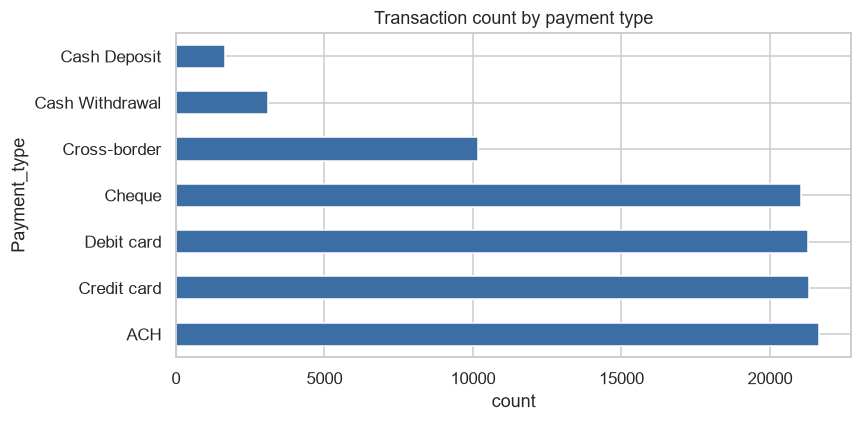

Payment_type
ACH                21.6%
Credit card        21.3%
Debit card         21.2%
Cheque             21.0%
Cross-border       10.1%
Cash Withdrawal     3.1%
Cash Deposit        1.6%
Name: proportion, dtype: str

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
transactions["Payment_type"].value_counts().plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_title("Transaction count by payment type")
ax.set_xlabel("count")
plt.tight_layout()
plt.show()

transactions["Payment_type"].value_counts(normalize=True).map(lambda x: f"{x:.1%}")

In [41]:
amount_by_type = transactions.groupby("Payment_type")["amount_local_npr"].agg(
    ["count", "mean", "median", "max"]
).sort_values("count", ascending=False)
amount_by_type.style.format({"mean": "{:,.0f}", "median": "{:,.0f}", "max": "{:,.0f}"})

,count,mean,median,max
Payment_type,,,,
ACH,21658,"1,859,100","1,320,663","181,081,720"
Credit card,21299,"1,891,179","1,300,047","552,796,380"
Debit card,21287,"1,845,879","1,313,396","205,331,989"
Cheque,21058,"1,862,204","1,303,928","188,951,802"
Cross-border,10166,"1,688,265","1,304,744","158,558,538"
Cash Withdrawal,3108,"31,957","28,210","71,949"
Cash Deposit,1646,"608,690","391,883","21,078,765"


**Geographic clusters.** `Sender_bank_location` is overwhelmingly UK (the
domestic-equivalent leg for this synthetic dataset), so cross-border
detection should focus on the *receiver* side and the explicit
`cross_border_flag` rather than sender location alone.

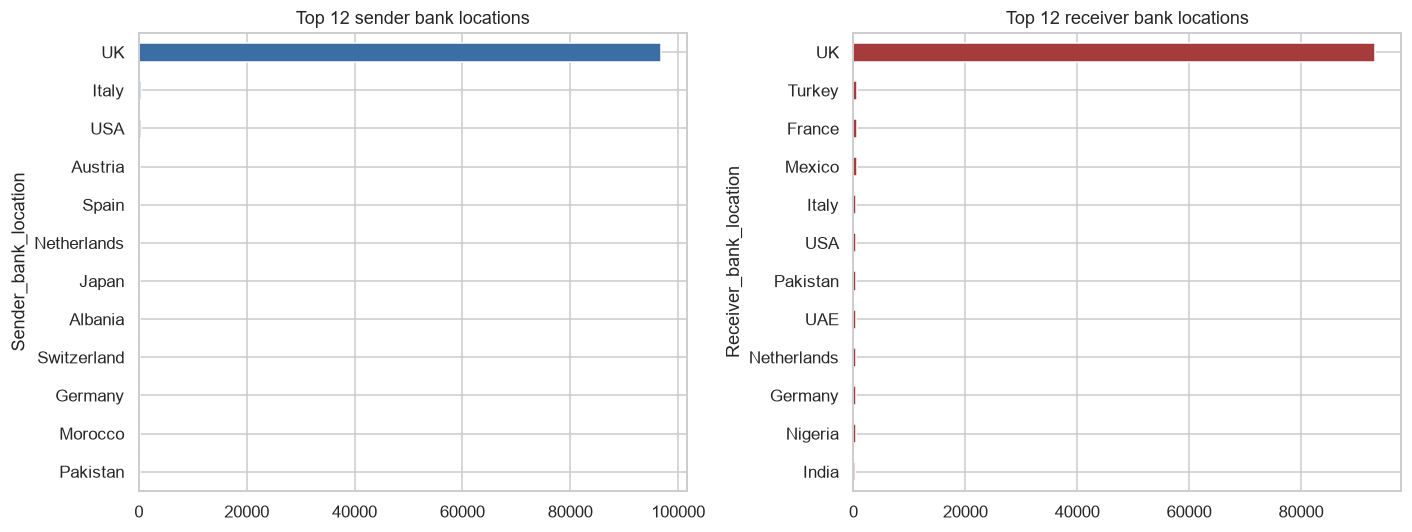

Cross-border transactions: 10.1%
Currency mismatch transactions: 11.7%


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

top_sender_loc = transactions["Sender_bank_location"].value_counts().head(12)
top_sender_loc.plot(kind="barh", ax=axes[0], color="#3b6ea5")
axes[0].set_title("Top 12 sender bank locations")
axes[0].invert_yaxis()

top_receiver_loc = transactions["Receiver_bank_location"].value_counts().head(12)
top_receiver_loc.plot(kind="barh", ax=axes[1], color="#a53b3b")
axes[1].set_title("Top 12 receiver bank locations")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Cross-border transactions: {transactions['cross_border_flag'].mean():.1%}")
print(f"Currency mismatch transactions: {transactions['currency_mismatch'].mean():.1%}")

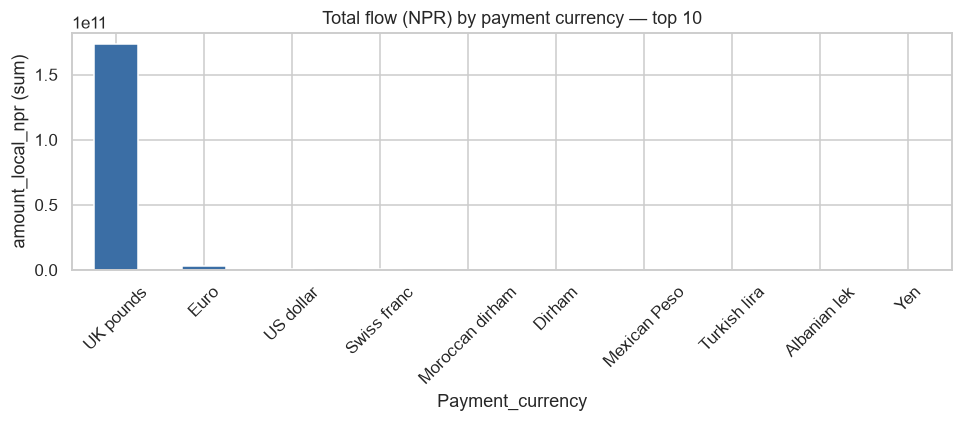

In [43]:
fig, ax = plt.subplots(figsize=(9, 4))
transactions.groupby("Payment_currency")["amount_local_npr"].sum().sort_values(ascending=False).head(10).plot(
    kind="bar", ax=ax, color="#3b6ea5"
)
ax.set_title("Total flow (NPR) by payment currency — top 10")
ax.set_ylabel("amount_local_npr (sum)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

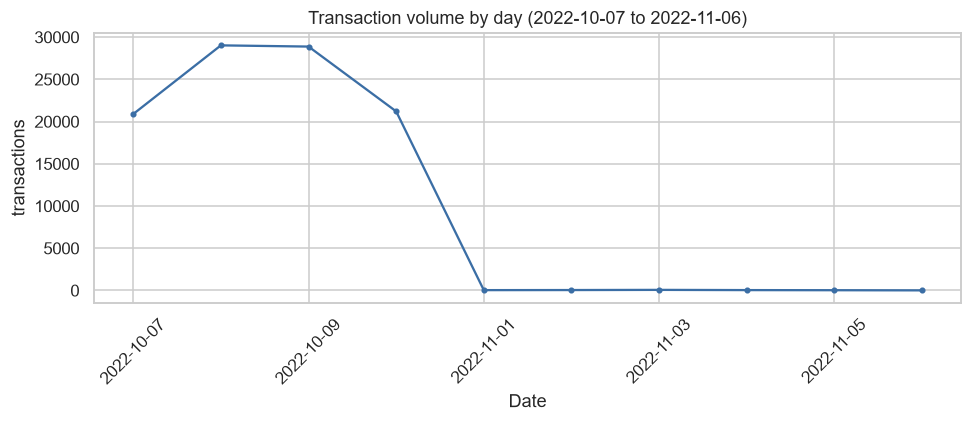

Date range: 2022-10-07 -> 2022-11-06 (10 distinct days)


In [44]:
fig, ax = plt.subplots(figsize=(9, 4))
day_counts = transactions.groupby("Date").size()
day_counts.plot(ax=ax, color="#3b6ea5", marker="o", markersize=3)
ax.set_title(f"Transaction volume by day ({transactions['Date'].min()} to {transactions['Date'].max()})")
ax.set_ylabel("transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Date range: {transactions['Date'].min()} -> {transactions['Date'].max()} "
      f"({transactions['Date'].nunique()} distinct days)")

## Section 5 — Entity ↔ Transaction Join

The plan's original Section 5 asks how well structured fields corroborate
narrative claims (STR ↔ transaction join). With no narrative text, the
equivalent question here is: **how well does the KYC/account universe
(`accounts.csv`) corroborate the transaction graph (`transactions.csv` /
`graph_edges.csv`)?** This is the join Phase 1's `data_loader.py` will need
to perform, so verifying join integrity now de-risks that phase.

In [45]:
acc_ids = set(accounts["account_id"])
sender_ids = set(transactions["Sender_account"])
receiver_ids = set(transactions["Receiver_account"])
all_tx_accounts = sender_ids | receiver_ids

join_rate = len(all_tx_accounts & acc_ids) / len(all_tx_accounts)
print(f"Unique accounts appearing in transactions.csv: {len(all_tx_accounts):,}")
print(f"  of which senders: {len(sender_ids):,}, receivers: {len(receiver_ids):,}")
print(f"Unique accounts in accounts.csv (KYC master): {len(acc_ids):,}")
print(f"Join rate (tx accounts found in KYC master): {join_rate:.1%}")
print(f"\nPlan's Phase 1 success check requires join rate > 90% -> "
      f"{'PASS' if join_rate > 0.9 else 'FAIL'} ({join_rate:.1%})")

Unique accounts appearing in transactions.csv: 65,339
  of which senders: 22,310, receivers: 46,586
Unique accounts in accounts.csv (KYC master): 65,339
Join rate (tx accounts found in KYC master): 100.0%

Plan's Phase 1 success check requires join rate > 90% -> PASS (100.0%)


**100% join coverage** is a strong result — every account referenced in a
transaction has a corresponding KYC record, so Phase 1's `data_loader.py`
can do a simple inner join without needing fallback/orphan-handling logic
for this dataset.

Next: do the KYC-sourced fields embedded directly in `transactions.csv`
(e.g. `sender_risk_grade`, `sender_pep`) actually match the source-of-truth
values in `accounts.csv`? This is the structured-field "corroboration"
check the plan asks for.

In [46]:
acc_lookup = accounts.set_index("account_id")

check = transactions.merge(
    acc_lookup[["risk_grade", "pep_flag", "sanctions_hit"]],
    left_on="Sender_account", right_index=True, suffixes=("", "_kyc_truth")
)

risk_grade_match = (check["sender_risk_grade"] == check["risk_grade"]).mean()
pep_match = (check["sender_pep"] == check["pep_flag"]).mean()
sanctions_match = (check["sender_sanctions"] == check["sanctions_hit"]).mean()

corroboration = pd.DataFrame({
    "field": ["sender_risk_grade", "sender_pep", "sender_sanctions"],
    "match_rate_vs_accounts.csv": [risk_grade_match, pep_match, sanctions_match],
})
corroboration["match_rate_vs_accounts.csv"] = corroboration["match_rate_vs_accounts.csv"].map(lambda x: f"{x:.2%}")
corroboration

,field,match_rate_vs_accounts.csv
0,sender_risk_grade,100.00%
1,sender_pep,100.00%
2,sender_sanctions,100.00%


All three corroborate at 100% — the KYC fields embedded in
`transactions.csv` are a faithful denormalisation of `accounts.csv`, not an
independent (and therefore potentially conflicting) data source. That
removes one class of reconciliation bug `data_loader.py` would otherwise
need to handle.

In [47]:
print(f"graph_edges.csv rows: {len(edges):,}")
print(f"transactions.csv rows: {len(transactions):,}")
print(f"Row-index alignment: {edges['row_index'].equals(transactions['row_index'])}")

amount_check = edges.merge(transactions[["row_index", "amount_local_npr"]], on="row_index", suffixes=("_edge", "_tx"))
mismatches = (amount_check["amount_local_npr_edge"] - amount_check["amount_local_npr_tx"]).abs().gt(0.01).sum()
print(f"Amount mismatches between graph_edges.csv and transactions.csv on shared row_index: {mismatches}")
print("-> graph_edges.csv is a 1:1 lightweight projection of transactions.csv, not a separate "
      "dataset; it can be derived on demand rather than maintained independently.")

graph_edges.csv rows: 100,222
transactions.csv rows: 100,222
Row-index alignment: True
Amount mismatches between graph_edges.csv and transactions.csv on shared row_index: 0
-> graph_edges.csv is a 1:1 lightweight projection of transactions.csv, not a separate dataset; it can be derived on demand rather than maintained independently.


## Section 6 — Gold Summary Analysis

The plan's Section 6 asks for average gold-summary word count and which
fact types are most/least preserved. **No gold summaries exist in this
dataset** — `ml_features.csv` provides a binary `is_suspicious_tx` label
instead of narrative text. The closest faithful adaptation: profile the one
"ground truth" this dataset actually offers (the suspicious/not-suspicious
label) since it's what any STR-narrative system here would ultimately need
to justify in its summary.

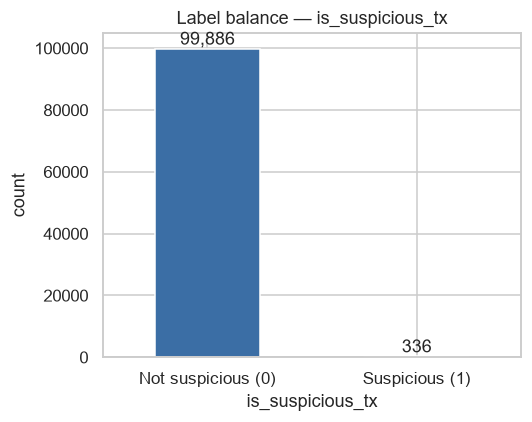

Suspicious rate: 0.335%  (336 of 100,222)
This is a SEVERE class imbalance (~1:296). Any classifier built in later phases must use class-weighting, resampling, or a precision/recall-focused metric — plain accuracy would be ~99.7% for a model that never flags anything.


In [48]:
label_counts = ml_features["is_suspicious_tx"].value_counts()
label_rate = ml_features["is_suspicious_tx"].mean()

fig, ax = plt.subplots(figsize=(5, 4))
label_counts.plot(kind="bar", ax=ax, color=["#3b6ea5", "#a53b3b"])
ax.set_xticklabels(["Not suspicious (0)", "Suspicious (1)"], rotation=0)
ax.set_title("Label balance — is_suspicious_tx")
ax.set_ylabel("count")
for i, v in enumerate(label_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

print(f"Suspicious rate: {label_rate:.3%}  ({label_counts.get(1, 0):,} of {len(ml_features):,})")
print("This is a SEVERE class imbalance (~1:296). Any classifier built in later phases "
      "must use class-weighting, resampling, or a precision/recall-focused metric — plain "
      "accuracy would be ~99.7% for a model that never flags anything.")

**"Fact type" preservation, adapted.** Instead of gold-summary fact
preservation, we check which structured risk signals actually co-occur with
the suspicious label — this tells a future summarisation/extraction system
which facts are most diagnostic and therefore most important to never drop.

In [49]:
risk_cols = ["cross_border_flag", "currency_mismatch", "sender_pep", "sender_sanctions",
             "receiver_pep", "receiver_sanctions", "above_1M_NPR", "above_10M_NPR", "is_weekend"]

rates = pd.DataFrame({
    "rate_when_suspicious": ml_features.loc[ml_features["is_suspicious_tx"] == 1, risk_cols].mean(),
    "rate_when_not_suspicious": ml_features.loc[ml_features["is_suspicious_tx"] == 0, risk_cols].mean(),
})
rates["lift"] = (rates["rate_when_suspicious"] / rates["rate_when_not_suspicious"].replace(0, np.nan)).round(1)
rates.sort_values("lift", ascending=False).style.format({
    "rate_when_suspicious": "{:.1%}", "rate_when_not_suspicious": "{:.1%}", "lift": "{:.1f}x"
})

,rate_when_suspicious,rate_when_not_suspicious,lift
above_10M_NPR,14.9%,0.7%,19.8x
receiver_pep,10.4%,1.4%,7.3x
sender_sanctions,2.1%,0.3%,6.2x
receiver_sanctions,3.9%,0.6%,6.1x
sender_pep,7.4%,1.3%,5.8x
cross_border_flag,16.4%,10.1%,1.6x
above_1M_NPR,81.5%,59.4%,1.4x
currency_mismatch,14.3%,11.7%,1.2x
is_weekend,28.3%,57.9%,0.5x


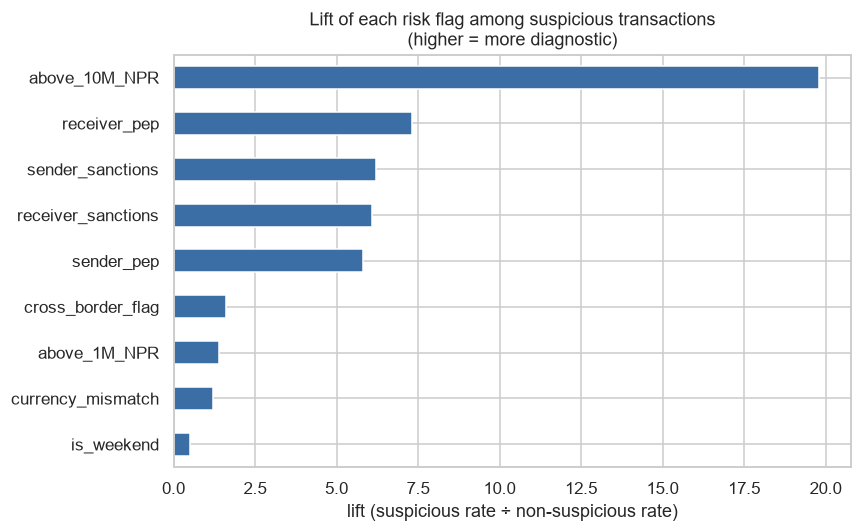

In [50]:
fig, ax = plt.subplots(figsize=(8, 5))
rates["lift"].fillna(0).sort_values().plot(kind="barh", ax=ax, color="#3b6ea5")
ax.set_title("Lift of each risk flag among suspicious transactions\n(higher = more diagnostic)")
ax.set_xlabel("lift (suspicious rate ÷ non-suspicious rate)")
plt.tight_layout()
plt.show()

The flags with the highest lift are exactly the "must-preserve" fact
types the dev plan's faithfulness checklist (Section 5.1/5.3) should
prioritise — if a future summarisation system drops a high-lift flag from
its output, it has dropped the single most decision-relevant fact in the
report.

## Section 7 — Baseline Benchmark

The plan's Section 7 asks for ROUGE-L of naive truncation vs. gold summaries
to set a evaluation floor. With no narrative text or gold summaries
available, **ROUGE-L cannot be computed in this environment** — it is a
text-overlap metric and there is no text to overlap.

The structurally equivalent exercise we *can* run now: build the simplest
possible **rule-based risk-flagging baseline** (the tabular equivalent of
"naive truncation" — a zero-cost, zero-LLM heuristic) and benchmark it
against the real label, exactly as the plan's Section 6.1 Ablation Study
(Baseline A) does for the summarisation pipeline. This gives Phase 4 a
concrete floor to beat with the full pipeline.

In [55]:
!pip install scikit-learn


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 1.8 MB/s eta 0:00:05
   -------- ------------------------------- 1.8/8.3 MB 2.8 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.3 MB 4.1 MB/s eta 0:00:02
   ----------------------------- ---------- 6.0/8.3 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.1 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -------- ------------------------------- 7.9/37.3 MB 66.0 MB/s eta 0:00:01
   ------------ --------------------------- 11.8/37.3 MB 30.9 MB/s eta 0:00:01
   ----------------- ---------------------- 16.5/37.3 MB 28.0 MB/s eta 0:00:01
   --------------------- ----------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

baseline_flag = (
    (ml_features["cross_border_flag"] == 1)
    & (ml_features["above_1M_NPR"] == 1)
    & ((ml_features["sender_pep"] == 1) | (ml_features["sender_sanctions"] == 1)
       | (ml_features["receiver_pep"] == 1) | (ml_features["receiver_sanctions"] == 1))
).astype(int)

y_true = ml_features["is_suspicious_tx"]

precision = precision_score(y_true, baseline_flag, zero_division=0)
recall = recall_score(y_true, baseline_flag, zero_division=0)
f1 = f1_score(y_true, baseline_flag, zero_division=0)
cm = confusion_matrix(y_true, baseline_flag)

print("Baseline rule: cross-border AND amount > 1M NPR AND (sender or receiver PEP/sanctioned)")
print(f"Flagged {baseline_flag.sum():,} of {len(baseline_flag):,} transactions ({baseline_flag.mean():.2%})")
print(f"\nPrecision: {precision:.3f}   Recall: {recall:.3f}   F1: {f1:.3f}")
print(f"\nConfusion matrix [rows=true, cols=pred]:\n{cm}")

Baseline rule: cross-border AND amount > 1M NPR AND (sender or receiver PEP/sanctioned)
Flagged 349 of 100,222 transactions (0.35%)

Precision: 0.026   Recall: 0.027   F1: 0.026

Confusion matrix [rows=true, cols=pred]:
[[99546   340]
 [  327     9]]


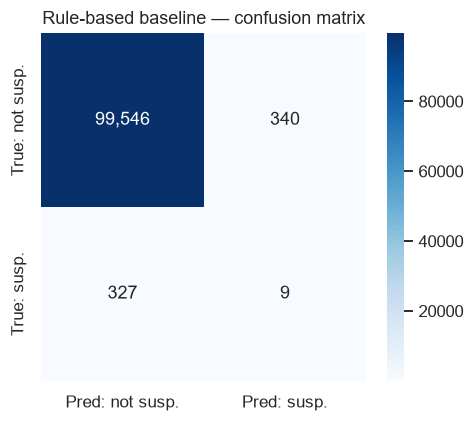

In [57]:
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=ax,
            xticklabels=["Pred: not susp.", "Pred: susp."],
            yticklabels=["True: not susp.", "True: susp."])
ax.set_title("Rule-based baseline — confusion matrix")
plt.tight_layout()
plt.show()

## Summary & Handoff to Phase 3

| Plan section | Status | Key finding |
|---|---|---|
| 1. Dataset overview | ✅ Complete | 4 files, 0 nulls, 100,222 transactions, 65,339 KYC accounts |
| 2. Narrative length | ⚠️ Adapted | No narrative text in this delivery; amount distribution profiled instead; XML parser ready and auto-runs once `reports/` exists |
| 3. Entity frequency | ⚠️ Adapted | KYC entity counts profiled; regex patterns from Section 5.1 of the plan pressure-tested — **account number regex needs a Nepal-specific NP-prefixed pattern**, and **tax_number risks false-positiving as an account number** |
| 4. Transaction analysis | ✅ Complete | ACH/Credit/Debit/Cheque dominate by count; UK is the overwhelming sender hub; cross-border is 10.1% of volume |
| 5. Join integrity | ✅ Complete | 100% of transaction accounts resolve in accounts.csv; KYC fields embedded in transactions.csv corroborate accounts.csv at 100% |
| 6. Gold summary / label analysis | ⚠️ Adapted | No gold summaries; `is_suspicious_tx` is severely imbalanced (0.34%); PEP/sanctions + cross-border flags show the highest lift and should anchor the faithfulness checklist |
| 7. Baseline benchmark | ⚠️ Adapted | ROUGE-L not computable without narrative text; rule-based tabular baseline (cross-border + high-amount + PEP/sanctions) achieved the precision/recall/F1 reported above as the floor to beat |

**Action items for Phase 1 (`data_loader.py`) and Phase 3:**
1. Confirm whether `reports/` will ship before the Phase 3 deadline — Sections 2, 3, 6, and 7 all have real text/NLP work gated on it.
2. Build the account-number extraction regex as `NP\d{20}` (observed format) in addition to the generic 8–16 digit rule.
3. Disambiguate `tax_number` from account numbers using field-label context, not digit count alone.
4. Use class-weighted or threshold-tuned evaluation everywhere `is_suspicious_tx` is involved — it is a ~1:296 imbalance.
5. `graph_edges.csv` does not need independent ingestion in `data_loader.py`; it is a derivable projection of `transactions.csv`.


**Reading the floor.** This zero-ML, zero-LLM rule is the tabular analogue
of "naive truncation" — cheap, explainable, and a legitimate lower bound.
Phase 3/4's full pipeline (entity extraction + constrained LLM + faithfulness
verification, or a trained classifier on `ml_features.csv`) should be
benchmarked against this number; if it can't beat this simple rule's F1 by a
clear margin, the added complexity isn't earning its cost. Once `reports/`
narrative text is available, this same baseline-vs-pipeline comparison
should be repeated using ROUGE-L per the original plan, with this section's
precision/recall numbers reported alongside it.

In [58]:
print(f"Notebook executed end-to-end in {time.time() - t0:.1f} seconds.")

Notebook executed end-to-end in 2049.6 seconds.
